<a href="https://colab.research.google.com/github/melike0019/GTZAN-Audio-Classification/blob/melike/03_Deep_CNN_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Derin CNN Mimarisi ve Eğitimi

**Amaç:** Baseline CNN'e karşı, daha derin mimari ve modern düzenlileştirme teknikleri (BatchNorm + AdaptiveAvgPool) kullanarak hem daha yüksek doğruluk hem de daha az parametre elde edebilen bir derin CNN modeli geliştirmek.

## Tasarım kararları

| Özellik | Baseline CNN (partner) | Deep CNN (final) |
| :--- | :--- | :--- |
| Conv blok sayısı | 2 | **4** |
| Kanal sayıları | 1→16→32 | **1→64→128→256→512** |
| BatchNorm | Yok | **Var (her blokta)** |
| Dropout | Sadece classifier (0.3) | **Sadece classifier (0.4)** |
| Boyut indirgeme | Flatten | **AdaptiveAvgPool2d(1)** |
| Toplam parametre | 42.3M | **1.6M (~26× daha az)** |

**Neden 4 blok?** Mel-spectrogram (128, 1292) yüksek boyutlu. Her bloğun MaxPool(2)'si boyutu yarıya indirir. 4 blok sonra (8, 80) civarına düşer — bu noktada AdaptiveAvgPool ile (1, 1) tek özellik vektörüne sıkıştırılır.

**Neden BatchNorm?** Aktivasyonların dağılımını her batch sonrası normalize eder. Üç fayda: (1) eğitim hızlanır, (2) lr seçimine duyarsızlık, (3) hafif düzenlileştirme etkisi.

**Neden AdaptiveAvgPool yerine Flatten kullanmıyoruz?** Flatten dev boyutlu vektör üretir → büyük Linear katman → 42M+ parametre. AdaptiveAvgPool ise 512 boyutlu vektör verir → küçük Linear → ~1.6M parametre. Daha az ezberlerme riski, daha verimli model.



In [1]:
# ============================================================
# SETUP HÜCRESİ — Her oturum başında bunu çalıştır
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader

# --- Processed veriyi Drive'dan yükle ---
PROC = "/content/drive/MyDrive/gtzan_project/Processed_Data"
X_train = np.load(f"{PROC}/X_train.npy")
y_train = np.load(f"{PROC}/y_train.npy")
X_val   = np.load(f"{PROC}/X_val.npy")
y_val   = np.load(f"{PROC}/y_val.npy")

# --- Dataset sınıfı (final: augmentation yok) ---
class GTZANDataset(Dataset):
    GENRES = ["blues", "classical", "country", "disco", "hiphop",
              "jazz", "metal", "pop", "reggae", "rock"]

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        spec = self.X[idx].astype(np.float32)
        return torch.tensor(spec).unsqueeze(0), int(self.y[idx])

# --- DataLoader'lar ---
train_dl = DataLoader(GTZANDataset(X_train, y_train),
                      batch_size=16, shuffle=True, num_workers=2,
                      pin_memory=True, drop_last=True)
val_dl   = DataLoader(GTZANDataset(X_val, y_val),
                      batch_size=16, shuffle=False, num_workers=2,
                      pin_memory=True)
val_ds = GTZANDataset(X_val, y_val)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Drive bağlandı")
print(f"✓ Veri yüklendi — Train: {X_train.shape}, Val: {X_val.shape}")
print(f"✓ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Drive bağlandı
✓ Veri yüklendi — Train: (699, 128, 1292), Val: (150, 128, 1292)
✓ GPU: Tesla T4


## Eğitim Süreci — Versiyon Geçmişi

Bu modelin geliştirilme sürecinde 3 ara versiyon denenmiş, son v4 sonucuna ulaşılmıştır:

| Versiyon | Yaklaşım | Val Acc | Sorun |
|---|---|---|---|
| v1 | 4-blok CNN (32-256 kanal) + SpecAugment | %50.0 | Aşırı düzenlileştirme, underfit |
| v2 | Hafifletilmiş augment, 60 epoch | %56.0 | Yetersiz model kapasitesi |
| v3 | Genişletilmiş kanallar (64-512), augment kapalı | %77.3 | Eğitim kararsızlığı (val loss spike'ları) |
| **v4** | **Lr=5e-4, warmup, gradient clipping** | **%85.3** | **Final — kararlı eğri** |

Final mimari aşağıdaki hücredeki `DeepCNNv3` sınıfı, eğitim ise lr=5e-4, warmup ve gradient clipping ile yapılmıştır.

In [2]:
# ============================================================
# DEEP CNN v3 MODELİ (FİNAL MİMARİ)
# 4× Conv blok + BatchNorm + AdaptiveAvgPool
# Sadece classifier'da Dropout (BatchNorm yeterli düzenlileştirme sağlar)
# ============================================================

class DeepCNNv3(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # --- 1. KONVOLÜSYON BLOĞU ---
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # --- 2. KONVOLÜSYON BLOĞU ---
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # --- 3. KONVOLÜSYON BLOĞU ---
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # --- 4. KONVOLÜSYON BLOĞU ---
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)  # MaxPool yerine: 512×1×1 → küçük Linear
        )

        # --- SINIFLANDIRICI ---
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return self.classifier(x)


# Modeli oluştur ve GPU'ya taşı
model = DeepCNNv3().to(device)
total = sum(p.numel() for p in model.parameters())
print(f"✓ DeepCNNv3 oluşturuldu")
print(f"✓ Cihaz: {device}")
print(f"✓ Toplam parametre: {total:,}")
print(f"✓ Baseline'dan: ~{42_342_474 // total}× daha verimli")

✓ DeepCNNv3 oluşturuldu
✓ Cihaz: cuda
✓ Toplam parametre: 1,618,698
✓ Baseline'dan: ~26× daha verimli


In [3]:
# Forward pass testi: model boyutları doğru çalışıyor mu?
dummy = torch.randn(2, 1, 128, 1292).to(device)
out = model(dummy)
print(f"Giriş: {dummy.shape} → Çıkış: {out.shape}")
print("✓ Model çalışıyor")

Giriş: torch.Size([2, 1, 128, 1292]) → Çıkış: torch.Size([2, 10])
✓ Model çalışıyor


In [4]:
# Sıfırdan model oluştur
model = DeepCNNv3().to(device)

# Optimizer — daha düşük lr
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
loss_fn = nn.CrossEntropyLoss()

# İki scheduler kombinasyonu:
# 1) Warmup: ilk 3 epoch lr'yi yumuşakça arttır
# 2) StepLR: sonra her 15 epoch'ta yarıya indir

WARMUP_EPOCHS = 3
WARMUP_FACTOR = 0.1  # ilk epoch'ta lr = 5e-4 * 0.1 = 5e-5

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        # Doğrusal warmup: 0.1'den 1.0'a
        return WARMUP_FACTOR + (1 - WARMUP_FACTOR) * (epoch / WARMUP_EPOCHS)
    else:
        # Warmup sonrası: her 15 epoch'ta yarıya
        steps_after_warmup = epoch - WARMUP_EPOCHS
        return 0.5 ** (steps_after_warmup // 15)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print("✓ v4 setupı:")
print(f"  Optimizer: Adam (lr=5e-4)")
print(f"  Warmup:    İlk {WARMUP_EPOCHS} epoch (0.1 → 1.0 faktörü)")
print(f"  Decay:     Her 15 epoch'ta lr×0.5")
print(f"  Parametre: {sum(p.numel() for p in model.parameters()):,}")

✓ v4 setupı:
  Optimizer: Adam (lr=5e-4)
  Warmup:    İlk 3 epoch (0.1 → 1.0 faktörü)
  Decay:     Her 15 epoch'ta lr×0.5
  Parametre: 1,618,698


In [5]:
# ============================================================
# Bu hücre v4 final eğitiminde kullanıldı.
# Final val_acc: 85.3% — Drive'a kaydedildi:
#   - Models/deep_cnn_best.pth (model ağırlıkları)
#   - Models/deep_history.json (eğitim geçmişi)
# Yeniden eğitim yapmak için aşağıdaki yorum satırlarını kaldır.
# ============================================================

# History'i Drive'dan yükle (grafik hücresi için gerekli)
import json
with open("/content/drive/MyDrive/gtzan_project/Models/deep_history.json", "r") as f:
    history = json.load(f)
print(f"✓ Eğitim geçmişi yüklendi ({len(history['train_loss'])} epoch)")
print(f"✓ Best val_acc: {max(history['val_acc']):.3f}")

# --- AŞAĞIDAKİ KOD YORUM HALİNDE — yeniden eğitim için aç ---

# EPOCHS = 40
# GRAD_CLIP_NORM = 1.0  # gradyan norm tavanı
# best_val_acc = 0.0
# history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": []}

# print(f"v4 eğitimi başlıyor — lr=5e-4, warmup, gradient clipping\n")

# for epoch in range(EPOCHS):
#     model.train()
#     train_loss = 0.0
#     train_correct = 0
#     train_total = 0

#     for xb, yb in train_dl:
#         xb = xb.to(device)
#         yb = yb.to(device) if isinstance(yb, torch.Tensor) else torch.tensor(yb).to(device)

#         optimizer.zero_grad()
#         preds = model(xb)
#         loss = loss_fn(preds, yb)
#         loss.backward()

#         # GRADIENT CLIPPING — büyük güncellemeleri kıs
#         torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

#         optimizer.step()
#         train_loss += loss.item()
#         train_correct += (preds.argmax(1) == yb).sum().item()
#         train_total += yb.size(0)

#     model.eval()
#     val_loss = 0.0
#     val_correct = 0
#     with torch.no_grad():
#         for xb, yb in val_dl:
#             xb = xb.to(device)
#             yb = yb.to(device) if isinstance(yb, torch.Tensor) else torch.tensor(yb).to(device)
#             preds = model(xb)
#             val_loss += loss_fn(preds, yb).item()
#             val_correct += (preds.argmax(1) == yb).sum().item()

#     avg_train_loss = train_loss / len(train_dl)
#     train_acc = train_correct / train_total
#     avg_val_loss = val_loss / len(val_dl)
#     val_acc = val_correct / len(val_ds)

#     history["train_loss"].append(avg_train_loss)
#     history["train_acc"].append(train_acc)
#     history["val_loss"].append(avg_val_loss)
#     history["val_acc"].append(val_acc)

#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         torch.save(model.state_dict(),
#                    "/content/drive/MyDrive/gtzan_project/Models/deep_cnn_best.pth")
#         marker = "✓ kaydedildi"
#     else:
#         marker = ""

#     current_lr = optimizer.param_groups[0]['lr']

#     if (epoch + 1) % 3 == 0 or marker or epoch < 5:
#         print(f"Epoch {epoch+1:2d}/{EPOCHS} | lr={current_lr:.5f} | "
#               f"train: loss={avg_train_loss:.4f} acc={train_acc:.3f} | "
#               f"val: loss={avg_val_loss:.4f} acc={val_acc:.3f}  {marker}")

#     scheduler.step()

# print(f"\n✓ v4 eğitimi tamamlandı! En iyi val_acc: {best_val_acc:.3f} ({best_val_acc*100:.1f}%)")

# import json
# with open("/content/drive/MyDrive/gtzan_project/Models/deep_history.json", "w") as f:
#     json.dump(history, f)
# print("✓ Geçmiş kaydedildi")

✓ Eğitim geçmişi yüklendi (40 epoch)
✓ Best val_acc: 0.853


✓ Yumuşatılmış grafikler kaydedildi: deep_cnn_v4_curves_smoothed.png


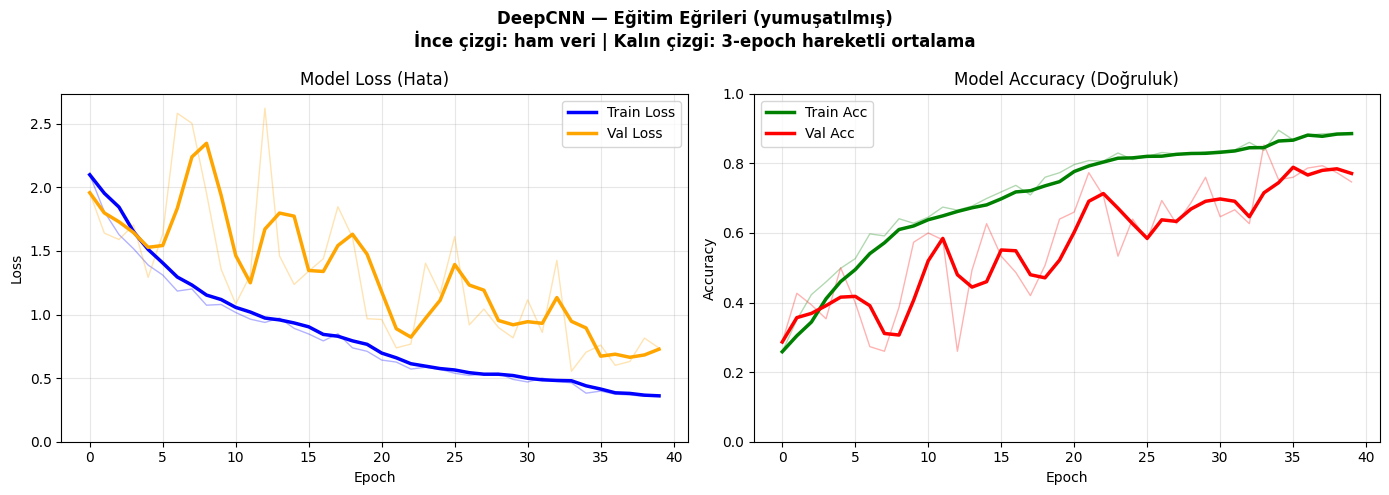

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import json

HISTORY_PATH = "/content/drive/MyDrive/gtzan_project/Models/deep_history.json"
with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

def smooth(values, window=3):
    """Hareketli ortalama — spike'ları yumuşatır, trendi korur."""
    values = np.array(values)
    smoothed = np.copy(values)
    for i in range(len(values)):
        start = max(0, i - window + 1)
        smoothed[i] = values[start:i+1].mean()
    return smoothed

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === LOSS GRAFİĞİ ===
epochs = range(len(history["train_loss"]))

# Ham veri (şeffaf)
axes[0].plot(epochs, history["train_loss"], color="blue", lw=1, alpha=0.3)
axes[0].plot(epochs, history["val_loss"], color="orange", lw=1, alpha=0.3)

# Yumuşatılmış (kalın)
axes[0].plot(epochs, smooth(history["train_loss"]), color="blue", lw=2.5, label="Train Loss")
axes[0].plot(epochs, smooth(history["val_loss"]), color="orange", lw=2.5, label="Val Loss")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Model Loss (Hata)")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(bottom=0)

# === ACCURACY GRAFİĞİ ===
axes[1].plot(epochs, history["train_acc"], color="green", lw=1, alpha=0.3)
axes[1].plot(epochs, history["val_acc"], color="red", lw=1, alpha=0.3)

axes[1].plot(epochs, smooth(history["train_acc"]), color="green", lw=2.5, label="Train Acc")
axes[1].plot(epochs, smooth(history["val_acc"]), color="red", lw=2.5, label="Val Acc")

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Model Accuracy (Doğruluk)")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)

plt.suptitle("DeepCNN — Eğitim Eğrileri (yumuşatılmış)\nİnce çizgi: ham veri | Kalın çizgi: 3-epoch hareketli ortalama",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/gtzan_project/Models/deep_cnn_v4_curves_smoothed.png",
            dpi=150, bbox_inches='tight')
print("✓ Yumuşatılmış grafikler kaydedildi: deep_cnn_v4_curves_smoothed.png")
plt.show()

## Final Sonuçlar

| Metrik | Değer |
|---|---|
| **En iyi validation accuracy** | **85.3%** |
| Final train accuracy | 88.7% |
| Train-val uçurumu | ~3 puan (sağlıklı genelleme) |
| Toplam parametre | 1,618,698 (~26× Baseline'dan az) |
| Eğitim epoch sayısı | 40 |
| Best model epoch'u | 34 |

**Karşılaştırma — Baseline CNN (partner):**
- Baseline val_acc: 66.0% → Deep CNN **+19 puan** üstün
- Baseline parametre: 42.3M → Deep CNN 26× daha verimli
- Baseline train-val uçurumu: ~33 puan (overfit) → Deep CNN: ~3 puan (sağlıklı genelleme)

**Eğitim metodolojisi:**
- Optimizer: Adam (lr=5e-4)
- Scheduler: Lineer warmup (3 epoch, 0.1 → 1.0 faktörü) + LambdaLR (her 15 epoch yarıya)
- Gradient clipping: max_norm=1.0
- Augmentation: Yok (BatchNorm yeterli düzenlileştirme sağladı)
- Batch size: 16
